# Galaxy SED Modelling and ELG Selection

This notebook demonstrates the galaxy SED modelling and emission-line
galaxy (ELG) selection pipeline used in the ELG–halo connection analysis.

The pipeline:

1. Uses aperture-based stellar particle data from IllustrisTNG simulations.
2. Separates stellar populations into old and young components.
3. Uses FSPS to model their spectral energy distributions.
4. Applies dust attenuation using calibrated optical depths.
5. Converts the model fluxes into DESI g, r and z magnitudes.
6. Applies DESI magnitude limits and ELG colour cuts.
7. Produces the resulting ELG halo catalogue.

Simulation data and derived pickle files are stored outside this repository.

In [8]:
# Imports
import sys
import numpy as np
import pandas as pd
import astropy.units as u
import pickle

sys.path.append(
    "/cosma8/data/dp004/dc-gilf1/projects/MG_project/ELG-halo-connection/src"
)

from elg_halo_connection.sed_model import GalaxySEDModel
from elg_halo_connection.data_processor import DataProcessor
from elg_halo_connection.tauv_calibration import DustAttenuationCalibrator

In [6]:
# Main simulation for analysis
simName = 'GR'
snapNum = 8
simPath = f'/cosma8/data/dp203/bl267/Data/ClusterSims/L302_N1136_{simName}/'
pickle_dir = '/cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/'
simInfo = [(simName, snapNum, simPath)]
minStellPart = 100

processor = DataProcessor(
    simInfo=simInfo,
    pickle_dir=pickle_dir,
    minStellPart=minStellPart,
    save_data=True,
    overwrite=False
)

# Aperture dictionary for all subhalos in simulation GR snapshot 8
apDict_GR_snap8 = processor.compute_all_apertures(
                simName=simName,
                snapNum=snapNum,
                R=30*u.kpc,
                ncpu=10,
                save_data = True,
                overwrite = False
            )

# Calibration sim
simName_cal = 'GR'
snapNum_cal = 19
simPath_cal = f'/cosma8/data/dp203/bl267/Data/ClusterSims/L302_N1136_{simName_cal}/'
simInfo_cal = [(simName_cal, snapNum_cal, simPath_cal)]

processor_cal = DataProcessor(simInfo = simInfo_cal, pickle_dir = pickle_dir, minStellPart = minStellPart, save_data = True, overwrite = False)

_, cal_subDict, cal_simDict, _ = processor_cal.load_data()
cal_subDict = cal_subDict[simName_cal][snapNum_cal]
cal_simDict = cal_simDict[simName_cal][snapNum_cal]


Aperture dictionary already exists for GR at snapshot 8!
Loading aperture dictionary from /cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/apDict_GR_snap8...
Successfully loaded aperture dictionary!
Opening saved data for GR, snapshot 19...
Finished loading data


In [9]:
# Galaxy catalogue for calibration
with open('/cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/GSWLC_catalogue', 'rb') as handle:
    df_GSWLC = pickle.load(handle)

# Set up dust attenuation calibration using GR snapshot 19
# and apply the calibrated model to GR snapshot 8 aperture data
GR_snap8_dustcalibrator = DustAttenuationCalibrator(cal_simDict, cal_subDict, df_GSWLC, minStellPart = minStellPart)

# Dictionary
alpha = -0.6
calibration_res_GR = GR_snap8_dustcalibrator.run_calibration(apDict = apDict_GR_snap8, alpha = alpha)
print(calibration_res_GR.keys())

Successfully assigned V-band optical depths to aperture dictionary!
dict_keys(['Optimal_Params', 'GSWLC', 'Aperture_Snapshot', 'Calibration_Snapshot'])


In [17]:
# DESI DR1 - DECALS DR9 flux data
with open('/cosma8/data/dp004/dc-gilf1/projects/MG_project/DESIDR1_LSDR9', 'rb') as handle:
    DESI_flux_df = pickle.load(handle)

_, _, headersDict_GR_snap8, _ = processor.load_data()
headersDict_GR_snap8 = headersDict_GR_snap8[simName][snapNum]
    
sed_model = GalaxySEDModel(
    numGals=None,
    headersDict=headersDict_GR_snap8,
    cal_res_dict=calibration_res_GR,
    DESI_flux_df=DESI_flux_df,
    minStellPart=100
)

print(f"Number of galaxies: {sed_model.numGals}")

Opening saved data for GR, snapshot 8...
Finished loading data
Number of galaxies: 123455


In [18]:
dust1 = 0.2 # Birth cloud V-band optical depth
numAgeBins = 30

magDict_GR_snap8 = sed_model.get_magDict(dust1 = 0.2, numAgeBins = 30)

Computing Young Fluxes: 100%|██████████| 123455/123455 [1:27:14<00:00, 23.58it/s] 


Successfully computed young SSP fluxes!


Computing Old Fluxes:   0%|          | 0/123455 [00:00<?, ?it/s]/cosma/apps/durham/dc-gilf1/vmpython3.12.4/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Computing Old Fluxes: 100%|██████████| 123455/123455 [38:14<00:00, 53.81it/s] 


Successfully computed old SSP fluxes!


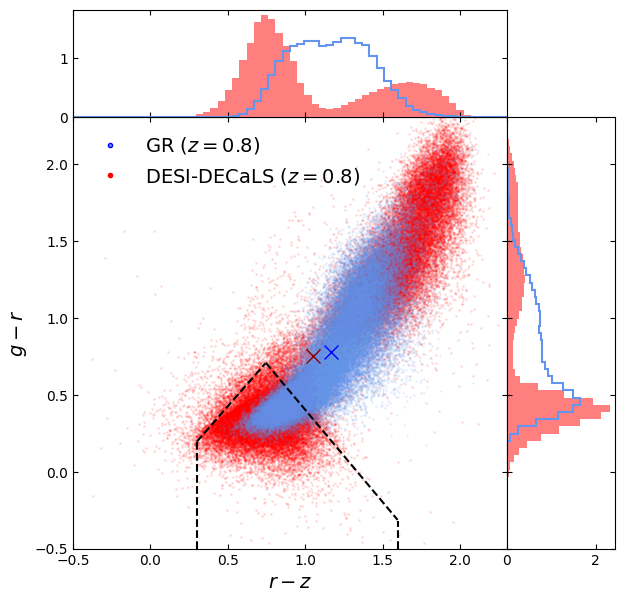

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

magDict = magDict_GR_snap8
headersDict = headersDict_GR_snap8

fig = plt.figure(figsize=(7, 7))
gs  = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.0, hspace=0.0)

ax_scatter  = fig.add_subplot(gs[1, 0])  # Bottom-Left
ax_hist_top = fig.add_subplot(gs[0, 0], sharex=ax_scatter)  # Top-Left
ax_hist_rt  = fig.add_subplot(gs[1, 1], sharey=ax_scatter)  # Bottom-Right

# Plot the Main Scatter
ax_scatter.scatter(magDict['Sim']['uncut']['r-z'], magDict['Sim']['uncut']['g-r'], s=1, alpha=0.1, color='cornflowerblue', zorder = 10)
ax_scatter.scatter(magDict['DESI']['uncut']['r-z'], magDict['DESI']['uncut']['g-r'], s=1, alpha=0.1, color='red')

ax_scatter.set_xlabel(r'$r - z$', fontsize=14)
ax_scatter.set_ylabel(r'$g - r$', fontsize=14)

custom_handle_sim = Line2D([0], [0], color='none', marker='o', markeredgecolor='blue', markerfacecolor='cornflowerblue', markersize=3)
custom_handle_DESI = Line2D([0], [0], color='none', marker='o', markeredgecolor='red', markerfacecolor='red', markersize=3)

DESI_redshift = np.mean(DESI_flux_df['redshift'])
sim_redshift  = headersDict['Redshift']

labelSim  = fr'$\text{{GR}} \ (z={round(sim_redshift, 2)})$'
labelDESI = fr'$\text{{DESI-DECaLS}} \ (z={round(DESI_redshift, 2)})$'
ax_scatter.legend(handles=[custom_handle_sim, custom_handle_DESI], labels=[labelSim, labelDESI], loc='upper left', frameon=False, fontsize=14)

ax_scatter.plot(np.mean(magDict['Sim']['uncut']['r-z']), np.mean(magDict['Sim']['uncut']['g-r']), color = 'blue', marker = 'x', zorder = 12, markersize = 10)
ax_scatter.plot(np.mean(magDict['DESI']['uncut']['r-z']), np.mean(magDict['DESI']['uncut']['g-r']), color = 'darkred', marker = 'x', zorder = 12, markersize = 10)

# Define common binning parameters
num_bins = 60
bin_range = (-0.5, 2.3)

# Plot the Top Histogram (r-z)
ax_hist_top.hist(magDict['Sim']['uncut']['r-z'], bins=num_bins, range=bin_range, histtype='step', 
                 color='cornflowerblue', linewidth=1.5, density=True)
ax_hist_top.hist(magDict['DESI']['uncut']['r-z'], bins=num_bins, range=bin_range, alpha = 0.5, 
                 color='red', linewidth=1.5, density=True)
plt.setp(ax_hist_top.get_xticklabels(), visible=False)

# Plot the Right Histogram (g-r)
ax_hist_rt.hist(magDict['Sim']['uncut']['g-r'], bins=num_bins, range=bin_range, orientation='horizontal', histtype='step', color='cornflowerblue', linewidth=1.5, density=True)

ax_hist_rt.hist(magDict['DESI']['uncut']['g-r'], bins=num_bins, range=bin_range, orientation='horizontal', color='red', linewidth=1.5, 
                density=True, alpha = 0.5)


plt.setp(ax_hist_rt.get_yticklabels(), visible=False)

# Clean up styling to match the paper style
for ax in [ax_scatter, ax_hist_top, ax_hist_rt]:
    ax.tick_params(direction='in', top=True, right=True, which='both')

ax_scatter.set_xlim(-0.5, 2.3)
ax_scatter.set_ylim(-0.5, 2.3)

# Overlay target selection lines for visual reference
color_line = 'black'
zorder_line = 11
r_z_vertex = (1.6 + 0.15) / (1.15 + 1.2)  # ~0.7447

# Vertical bounds
ax_scatter.vlines(0.3, -0.5, (1.15 * 0.3 - 0.15), color=color_line, linestyle='--', zorder = zorder_line)
ax_scatter.vlines(1.6, -0.5, (-1.2 * 1.6 + 1.6), color=color_line, linestyle='--', zorder = zorder_line)

# Upper sloped bounds
r_zArray1 = np.arange(0.3, r_z_vertex, 0.01)
ax_scatter.plot(r_zArray1, 1.15 * r_zArray1 - 0.15, color=color_line, linestyle='--', zorder = zorder_line)

r_zArray2 = np.arange(r_z_vertex, 1.6, 0.01)
ax_scatter.plot(r_zArray2, -1.2 * r_zArray2 + 1.6, color=color_line, linestyle='--', zorder = zorder_line)

plt.show()